In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38


In [4]:
df.shape

(3803, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3803 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   f

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.head(3)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15


**PROPERTY TYPE**

In [8]:
df['property_type'].isna().sum()

np.int64(0)

<Axes: xlabel='property_type'>

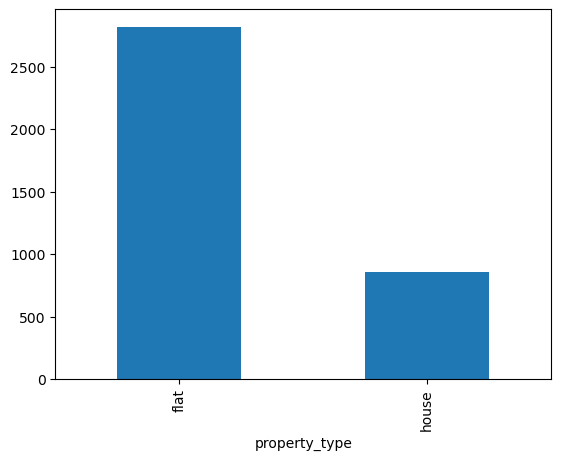

In [9]:
df['property_type'].value_counts().plot(kind='bar')

**OBSERVATIONS**

Flats are in majority - about 75%

No missing values

**SOCIETY**

In [10]:
df['society'].isna().sum()

np.int64(1)

In [11]:
df[df['society'].isna()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2693,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


In [12]:
arr = df['society'].values.tolist()
len(list(set(arr)))

677

In [13]:
df['society'].value_counts(normalize=True).cumsum().head(75)

society
independent                             0.132209
tulip violet                            0.152612
ss the leaf                             0.172470
dlf new town heights                    0.183896
shapoorji pallonji joyville gurugram    0.195321
                                          ...   
the close north                         0.554135
ramsons kshitij                         0.557671
umang monsoon breeze                    0.561208
ats kocoon                              0.564744
ireo the corridors                      0.568009
Name: proportion, Length: 75, dtype: float64

In [14]:
total_society = df['society'].value_counts()

frequency = {
    'Very high (>100)' : (total_society > 100).sum(),
    'High (50-100)' : ((total_society >= 50) & (total_society <= 100)).sum(),
    'Average (10-49)' : ((total_society >= 10) & (total_society <= 49)).sum(),
    'Low (1-10)' : ((total_society > 1) & (total_society <= 10)).sum(),
    'Very Low (1)' : (total_society == 1).sum()
}


In [15]:
frequency

{'Very high (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (1-10)': np.int64(279),
 'Very Low (1)': np.int64(308)}

<Axes: xlabel='society'>

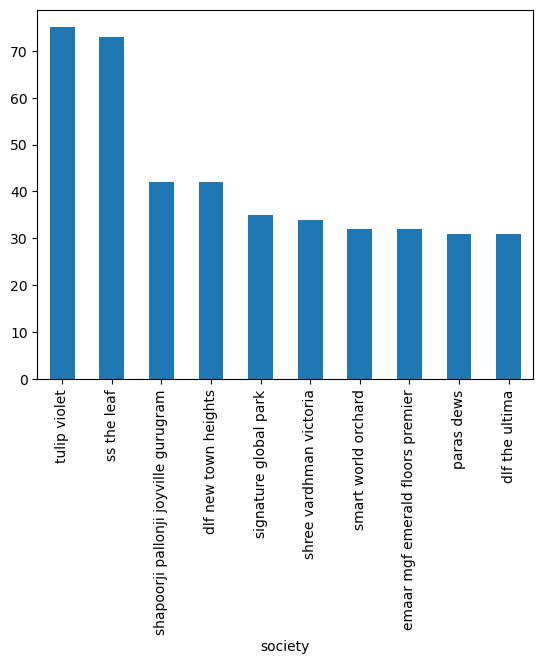

In [16]:
#top 10 society of Gurgaon 
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind = 'bar')

# OBSERVATION

* Around 13% of the societies are independent
* There are total of 676 societies
* The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
  - Very High (>100): Only 1 society has more than 100 listings.
  - High (50-100): 2 societies have between 50 to 100 listings.
  - Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
  - Low (2-9): 273 societies have between 2 to 9 listings.
  - Very Low (1): A significant number, 308 societies, have only 1 listing.
* 1 missing value


**SECTOR**

In [17]:
df['sector'].value_counts()

sector
sohna road    166
sector 85     108
sector 102    107
sector 92     100
sector 69      93
             ... 
sector 30       5
sector 80       5
sector 73       3
sector 88       3
sector 27       3
Name: count, Length: 104, dtype: int64

In [18]:
#Total number of sectors
total_sec = df['sector'].values.tolist()
len(list(set(total_sec)))

104

In [19]:
df['sector'].isna().sum()

np.int64(0)

In [20]:
df['sector'].value_counts(normalize=True).cumsum().head(50)

sector
sohna road    0.045145
sector 85     0.074517
sector 102    0.103617
sector 92     0.130813
sector 69     0.156106
sector 90     0.180310
sector 81     0.203971
sector 65     0.227631
sector 109    0.251020
sector 79     0.271689
sector 104    0.290454
sector 33     0.309219
sector 83     0.327713
sector 43     0.345390
sector 50     0.362796
sector 86     0.380201
sector 37d    0.397335
sector 95     0.414196
sector 2      0.431058
sector 107    0.447376
sector 108    0.463421
sector 89     0.478923
sector 56     0.494153
sector 48     0.509111
sector 70a    0.523797
sector 37     0.537939
sector 26     0.551537
sector 70     0.565135
sector 4      0.578461
sector 84     0.591787
sector 49     0.604841
sector 67     0.617623
sector 66     0.630133
sector 28     0.642100
sector 113    0.653794
sector 25     0.665216
sector 99     0.676639
sector 103    0.688061
sector 61     0.699211
sector 82     0.710362
sector 7      0.720968
sector 106    0.731303
sector 12     0.741093
mane

<Axes: xlabel='sector'>

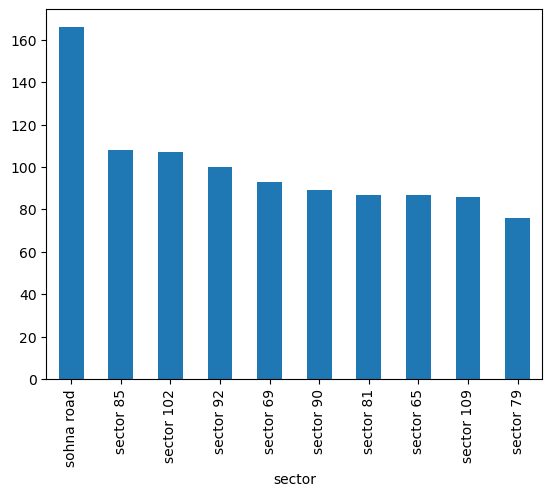

In [21]:
#top 10 sectors 
df['sector'].value_counts().head(10).plot(kind='bar')

In [22]:
total_sector = df['sector'].value_counts()

frequency = {
    'Very high (>100)' : (total_sector > 100).sum(),
    'High (50-100)' : ((total_sector >= 50) & (total_sector <= 100)).sum(),
    'Average (10-49)' : ((total_sector >= 10) & (total_sector <= 49)).sum(),
    'Low (1-10)' : ((total_sector > 1) & (total_sector <= 10)).sum(),
    'Very Low (1)' : (total_sector == 1).sum()
}

In [23]:
frequency

{'Very high (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(60),
 'Low (1-10)': np.int64(18),
 'Very Low (1)': np.int64(0)}

# OBSERVATION
* there are total of 104 sectors
* there are no null values
* Frequency distribution of the data:
  - Very High (>100): Only 3 sectors has more than 100 listings.
  - High (50-100): 25 sectors have between 50 to 100 listings.
  - Average (10-49): 60 sectors fall in this range with 10 to 49 listings each.
  - Low (2-9): 10 sectors have between 2 to 9 listings.
  - Very Low (1): No sector in this range
  

**PRICE**

In [24]:
df['price'].isna().sum()

np.int64(17)

In [25]:
df['price'].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

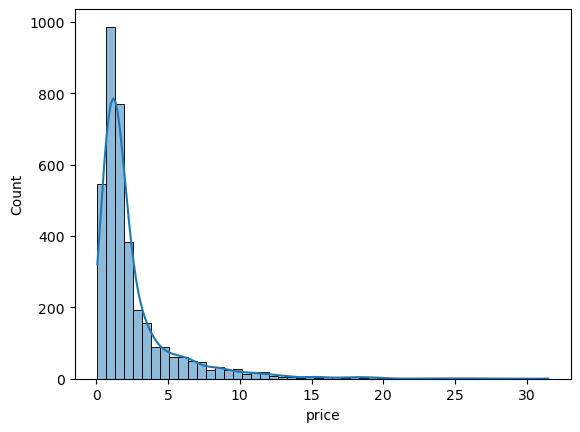

In [26]:
sns.histplot(df['price'],kde=True,bins=50)

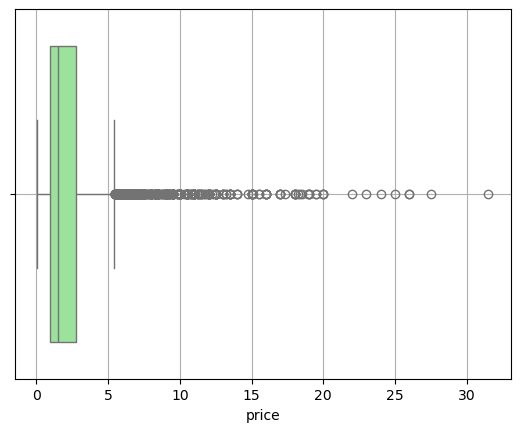

In [27]:
sns.boxplot(x=df['price'],color = 'lightgreen')
plt.grid()

* Descriptive Statistics

  - There are 17 missing values
  - Mean price - Approximately 2.5Cr
  - Median price - Approximately 1.52 Cr
  - Standard Deviation - Approximately 2.98 , indicates variability in price
  - Range - Minimum value is 0.070 Cr and Maximum value is 31.5 Cr
  - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.

* Visualizations:
  - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
  - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

In [28]:
#skewness and kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.2791704733134623 14.933372629214258


**Skewness**: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis**: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [29]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64

Quantile Analysis
* Only 1% properties are below 0.25Cr
* 5% are below 0.370Cr
* 95% are below 8.5Cr
* 99% are below 15.264

In [30]:
# Indentify the potential outlier 
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.8)

In [31]:
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print('Lower Bound: ',lower_bound,'Upper_bound: ',upper_bound)

Lower Bound:  -1.7500000000000002 Upper_bound:  5.45


In [32]:
outliers = df[(df['price']<lower_bound) | (df['price']>upper_bound)]
outliers.shape

(425, 23)

In [33]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

Outlier Analysis (using IQR method)

* Based on the IQR method , there are 425 properties which are considered as outlier
* These outliers has mean of 9.235Cr
* The range of these outliers are from 5.56 to 31.5Cr

<Axes: xlabel='price'>

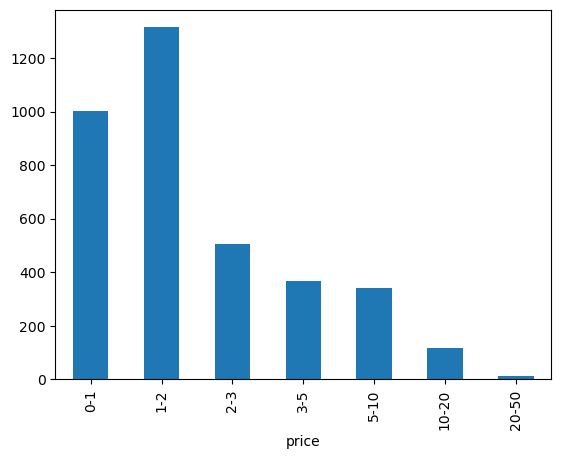

In [34]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

* The majority of properties are priced in the '1-2'Cr and '2-3'Cr range
* There's significant drop in the number of properties priced above 5Cr

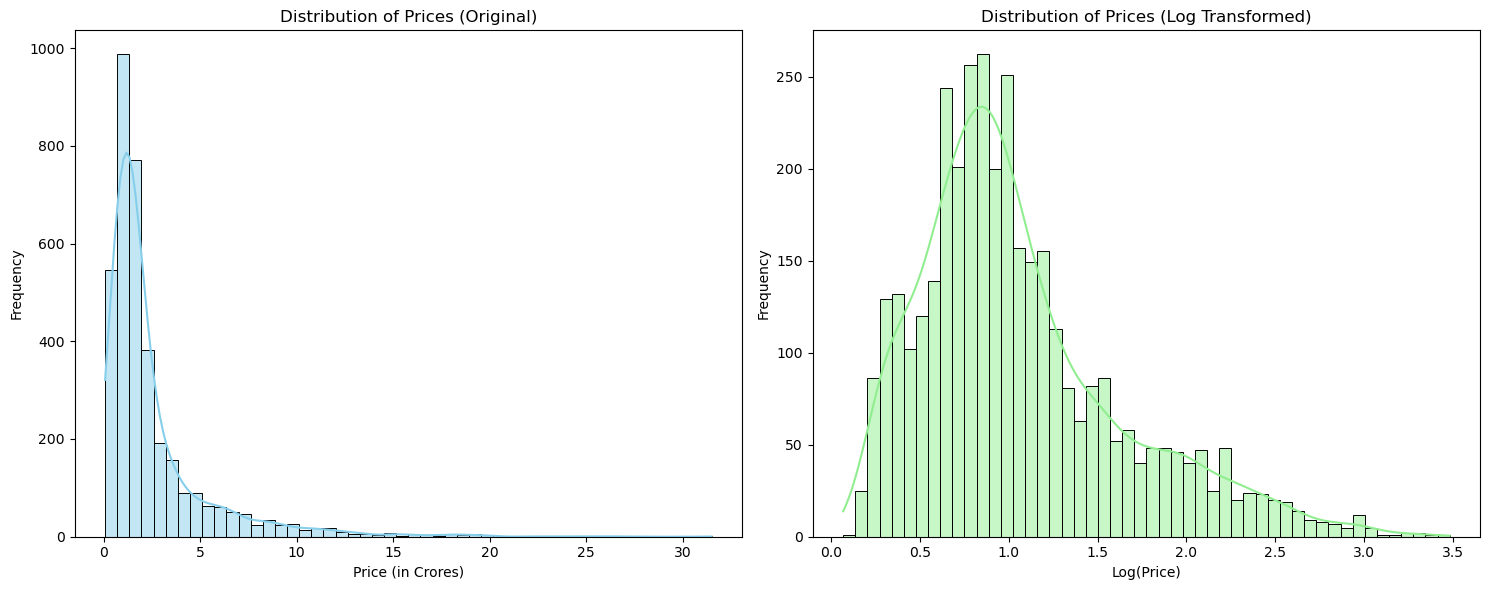

In [35]:
plt.figure(figsize=(15,6))

#Distribution plot without log transformation
plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [36]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255315 0.9646692415449296


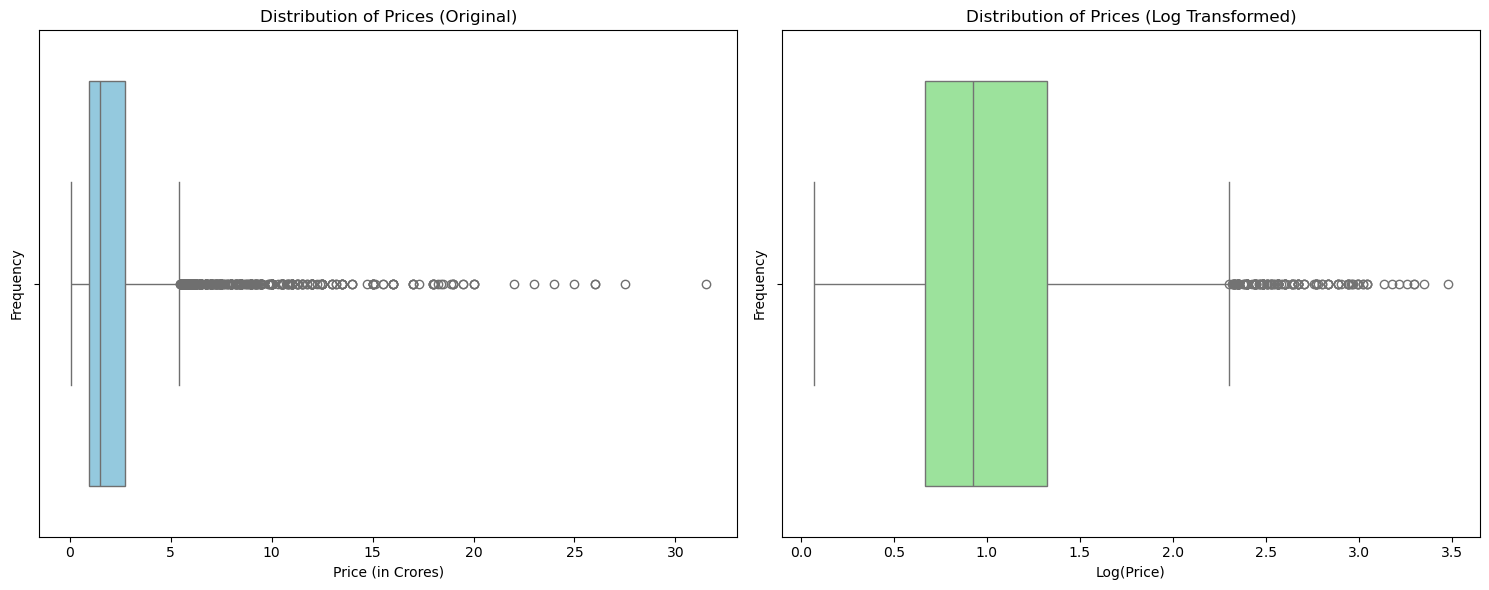

In [37]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**price_per_sqft**

In [38]:
df['price_per_sqft'].isna().sum()

np.int64(17)

In [39]:
df['price_per_sqft'].describe()

count      3660.000000
mean      13892.668306
std       23210.067190
min           4.000000
25%        6817.250000
50%        9020.000000
75%       13880.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

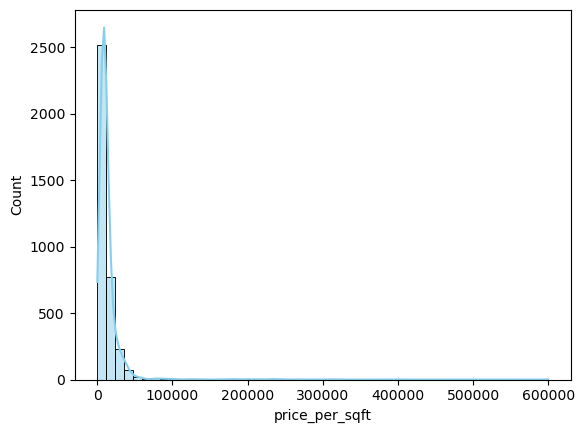

In [40]:
sns.histplot(df['price_per_sqft'],bins=50,color='skyblue',kde=True)

<Axes: xlabel='price_per_sqft'>

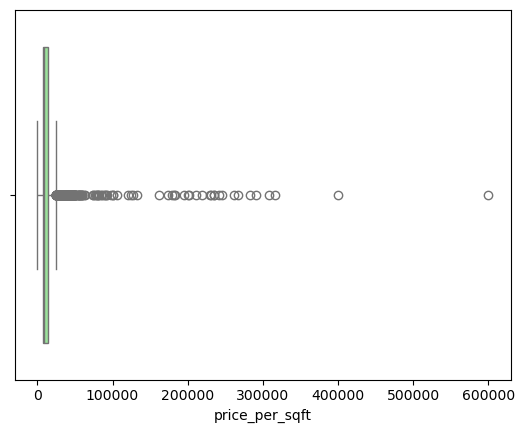

In [41]:
sns.boxplot(x=df['price_per_sqft'],color='lightgreen')

# OBSERVATION
* There are 17 null values
  
 DISCRIPTIVE STATISTICS
* The mean for price per sqft is around 13892.66
* The median for price per sqft is around 9020
* The standard deviation is 23210 which indicates high variability
* The minimum and maximum value is 4 and 600000 which could be outliers

 VISUALIZATION
* From the histplot we can say that is it Right Skewed
* The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers
* Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000

In [42]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


**BATHROOM**

In [43]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

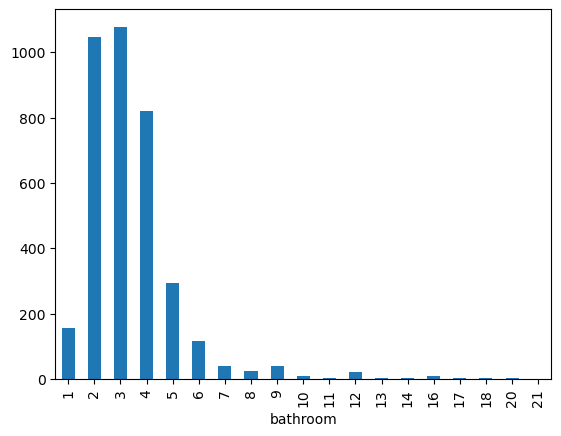

In [44]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

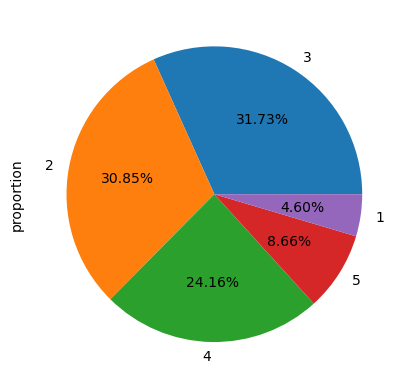

In [45]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# OBSERVATION
- Most of the properties have 2-4 number of bathrom
- No null value

**BALCONY**

In [46]:
df['balcony'].value_counts()

balcony
3+    1172
3     1074
2      884
1      365
0      182
Name: count, dtype: int64

In [47]:
df['balcony'].isna().sum()

np.int64(0)

**BEDROOM**

In [48]:
df['bedRoom'].isna().sum()

np.int64(0)

In [49]:
df['bedRoom'].value_counts().sort_index()

bedRoom
1      124
2      942
3     1496
4      660
5      210
6       74
7       28
8       30
9       41
10      20
11       1
12      28
13       4
14       1
16      12
18       2
19       2
20       1
21       1
Name: count, dtype: int64

<Axes: xlabel='bedRoom'>

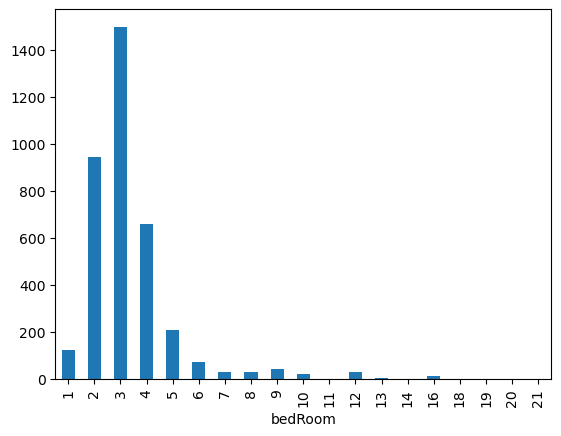

In [50]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='count'>

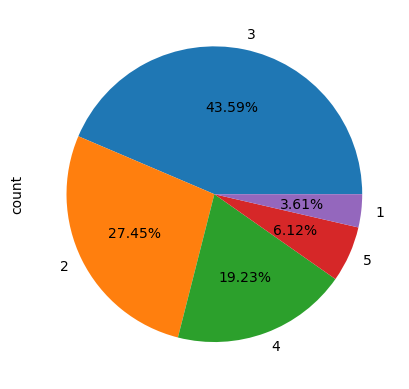

In [51]:
df['bedRoom'].value_counts().head().plot(kind='pie',autopct='%0.2f%%')

<Axes: xlabel='bedRoom'>

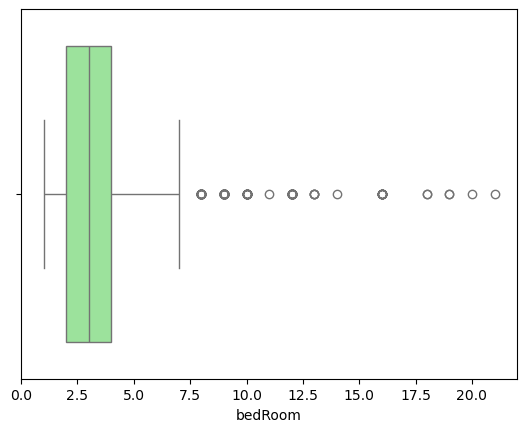

In [52]:
sns.boxplot(x=df['bedRoom'],color='lightgreen')

In [53]:
(df['bedRoom'].value_counts().sort_index().head(5).sum()/df['bedRoom'].value_counts().sort_index().sum())*100

np.float64(93.3369594778352)

# OBSERVATIONS
* 93.33% of the total rooms are in the range of 1-5
* There are some outliers (>18)
* No null value

In [54]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

In [55]:
df['floorNum'].value_counts()

floorNum
3.0     498
2.0     493
1.0     351
4.0     316
8.0     195
6.0     183
10.0    179
7.0     176
5.0     169
9.0     161
12.0    158
0.0     129
11.0    113
14.0    112
15.0     80
16.0     52
17.0     46
13.0     42
18.0     36
19.0     33
20.0     26
21.0     16
23.0     14
22.0     13
24.0     11
25.0      9
27.0      8
26.0      5
30.0      5
33.0      4
28.0      4
29.0      3
31.0      3
32.0      2
43.0      2
34.0      2
39.0      2
35.0      2
44.0      1
45.0      1
51.0      1
38.0      1
40.0      1
Name: count, dtype: int64

In [56]:
df['floorNum'].value_counts().sort_index().head(20).sum()/df['floorNum'].value_counts().sort_index().sum()

np.float64(0.9628212137780208)

In [57]:
df['floorNum'].isna().sum()

np.int64(19)

In [58]:
df['floorNum'].describe()

count    3658.000000
mean        6.798250
std         6.012454
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

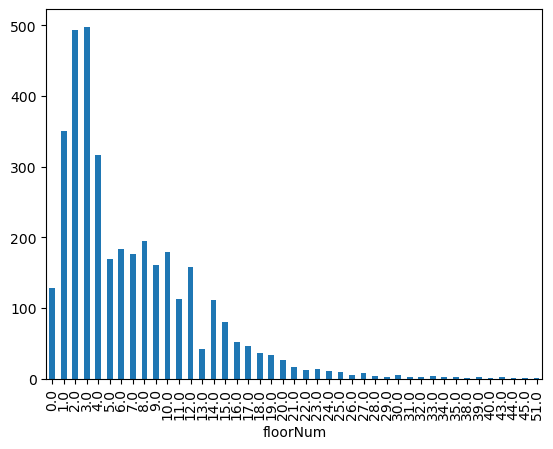

In [59]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='floorNum'>

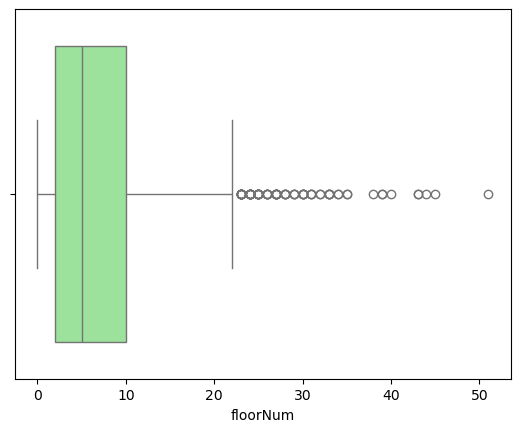

In [60]:
sns.boxplot(x=df['floorNum'],color='lightgreen')

# OBSERVATIONS
* 96% of the properties are within 0-20th floor
* Around 4% of the properties are above 20th floor
* From the boxplot we can conclude that above the wisker value lies the outliers
* The interquartile range lies between 2nd and 10th floor

## FACING

In [61]:
df['facing'].isna().sum()

np.int64(1045)

In [62]:
df['facing'].fillna('NA',inplace=True)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_6819/3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [63]:
df['facing'].value_counts()

facing
NA            1045
North-East     623
East           623
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

## AGE POSSESSION

In [64]:
df['agePossession'].isna().sum()

np.int64(0)

In [65]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         563
Undefined              306
Old Property           303
Under Construction     266
Name: count, dtype: int64

## BUILT UP AREA

In [66]:
#super_builtup_area
df['super_built_up_area'].value_counts()

super_built_up_area
1650.0    37
1950.0    37
1578.0    25
2000.0    25
1640.0    22
          ..
1454.0     1
3764.0     1
1110.0     1
2295.0     1
2965.0     1
Name: count, Length: 593, dtype: int64

In [67]:
df['super_built_up_area'].isna().sum()

np.int64(1802)

In [68]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

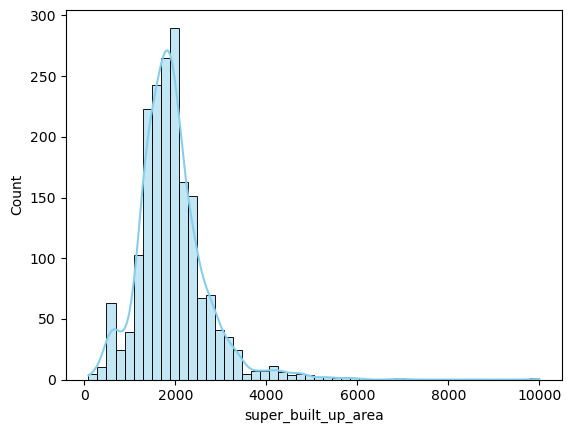

In [69]:
sns.histplot(x=df['super_built_up_area'].dropna(),bins=50,color='skyblue',kde=True)

In [70]:
df[(df['super_built_up_area'] > 900) & (df['super_built_up_area']<2600)].value_counts().sum()/df['super_built_up_area'].dropna().value_counts().sum()

np.float64(0.23626666666666668)

<Axes: xlabel='super_built_up_area'>

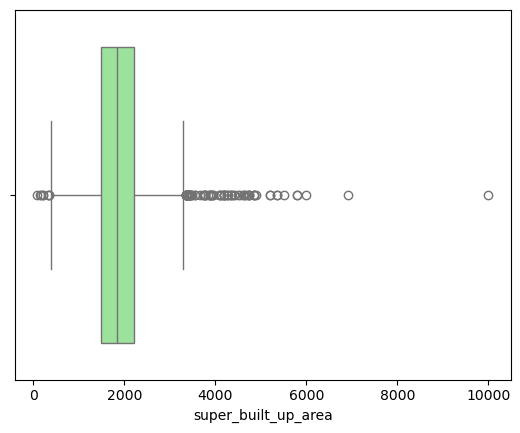

In [71]:
sns.boxplot(x=df['super_built_up_area'].dropna(),color='lightgreen')

# OBSERVATION
* Maximum of the properties have super built up area ranging from 900-2500
* From the bar graph we can conclude that the graph is right skewed
* The IQR range is approximately 1480sq.ft - 2215sq.ft
* There are some outliers which are indicated beyond the wisker value

In [72]:
#built_up_area
df['built_up_area'].isna().sum()

np.int64(1987)

In [73]:
df['built_up_area'].value_counts()

built_up_area
1800.0    41
3240.0    37
1900.0    34
2700.0    33
1350.0    33
          ..
2646.0     1
3160.0     1
4770.0     1
1785.0     1
5490.0     1
Name: count, Length: 644, dtype: int64

In [74]:
df['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

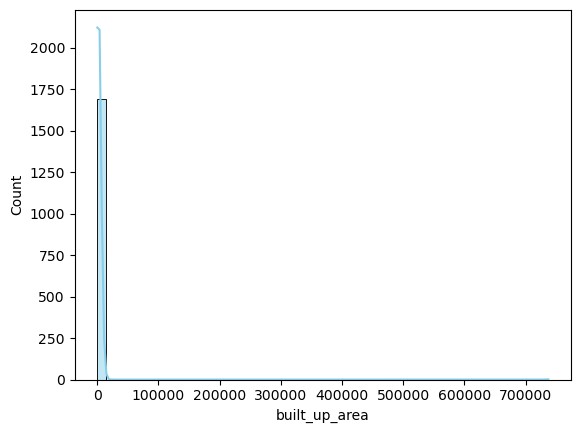

In [75]:
sns.histplot(x=df['built_up_area'].dropna(),bins=50,color='skyblue',kde='False')

<Axes: xlabel='built_up_area'>

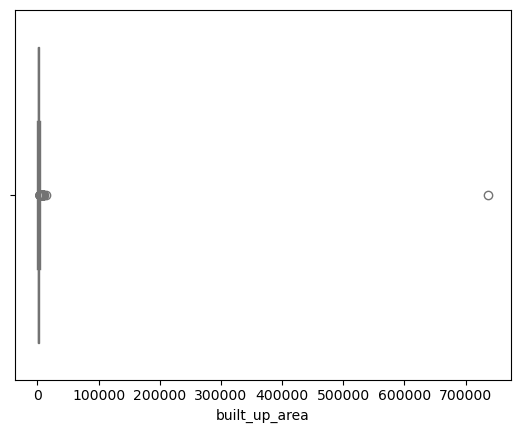

In [76]:
sns.boxplot(x=df['built_up_area'].dropna(),color='lightgreen')

* Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft
* There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution
* The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers

In [77]:
#Carpet area
df['carpet_area'].value_counts()

carpet_area
1400.000000    42
1800.000000    35
1600.000000    35
1200.000000    31
1500.000000    29
               ..
497.000000      1
1416.000000     1
2229.000000     1
553.802655      1
1741.000000     1
Name: count, Length: 733, dtype: int64

In [78]:
df['carpet_area'].isna().sum()

np.int64(1805)

In [79]:
df['carpet_area'].describe()

count      1872.000000
mean       2529.179507
std       22799.836449
min          15.000000
25%         843.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

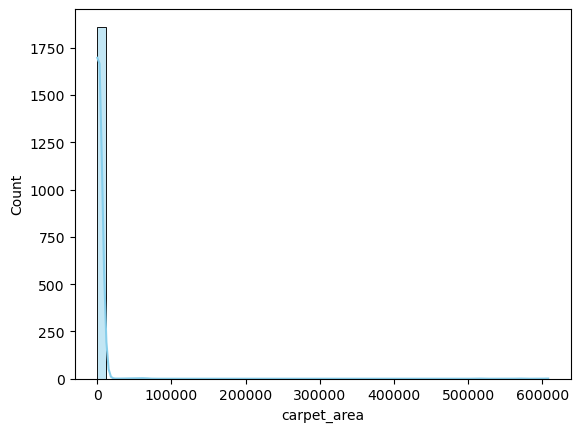

In [80]:
sns.histplot(x=df['carpet_area'].dropna(),bins=50,color='skyblue',kde=True)

<Axes: xlabel='carpet_area'>

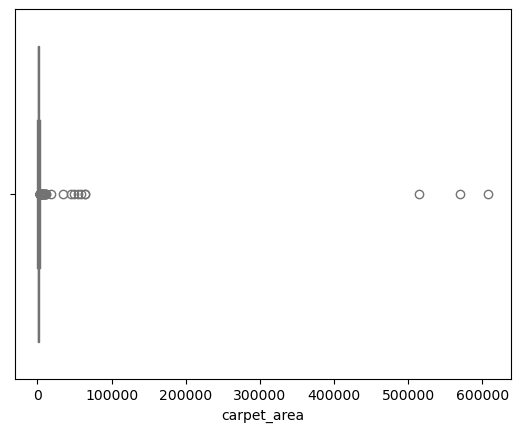

In [81]:
sns.boxplot(x=df['carpet_area'].dropna(),color='lightgreen')

In [82]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

In [83]:
df.iloc[:,-6:]

,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,8
1,1,0,0,0,0,38
2,0,0,0,0,0,15
3,0,0,0,0,0,49
4,1,0,0,1,1,174
...,...,...,...,...,...,...
3798,0,0,0,0,0,73
3799,1,1,1,0,0,160
3800,0,0,0,0,1,67
3801,1,1,1,0,0,76


# ADDITIONAL ROOMS

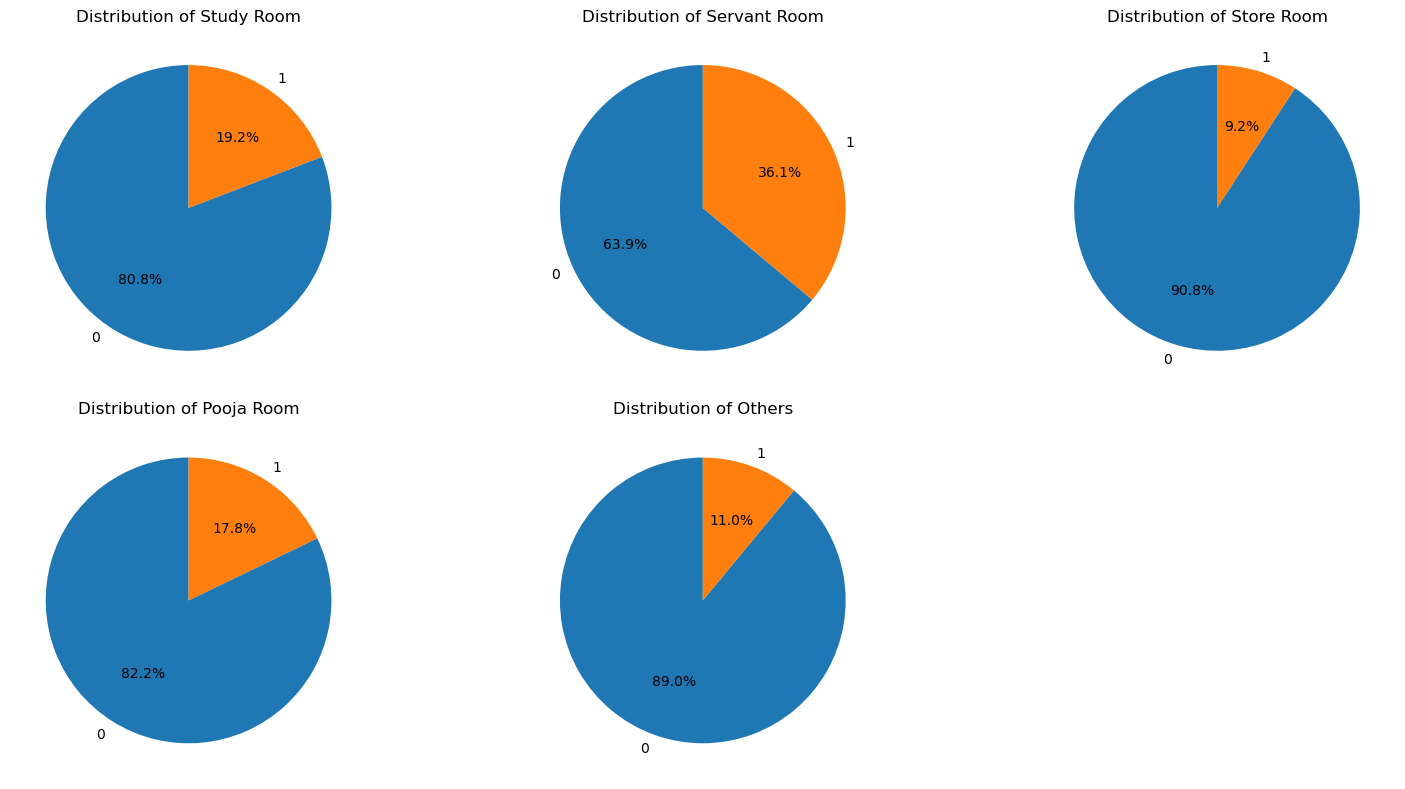

In [84]:
plt.figure(figsize=(16,8))

for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

**FURNISHING TYPE**

In [85]:
# 0 --> Unfurnished flat
# 1 --> Semi-furnished flat
# 2 --> furnished flat
df['furnishing_type'].value_counts()

furnishing_type
0    2411
1    1059
2     207
Name: count, dtype: int64

<Axes: ylabel='count'>

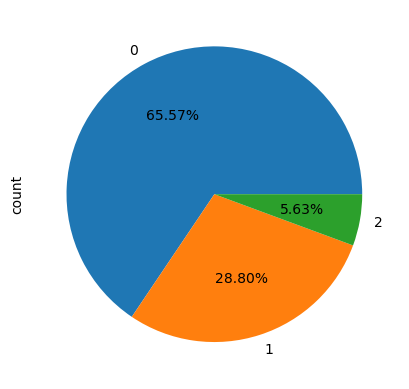

In [87]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [88]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38


In [90]:
df['luxury_score'].isna().sum()

np.int64(0)

In [91]:
df['luxury_score'].describe()

count    3677.000000
mean       71.512918
std        53.059082
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

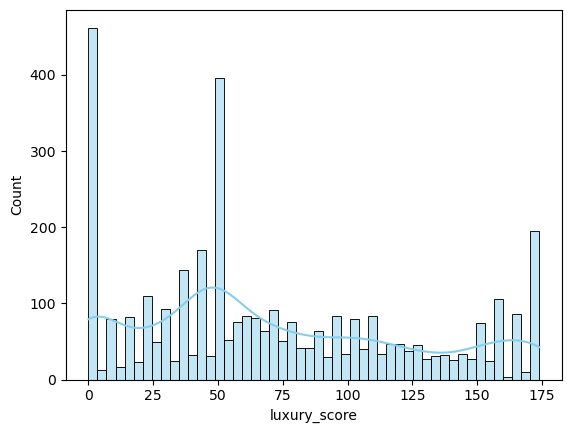

In [92]:
sns.histplot(x=df['luxury_score'],bins=50,color='skyblue',kde=True)

<Axes: xlabel='luxury_score'>

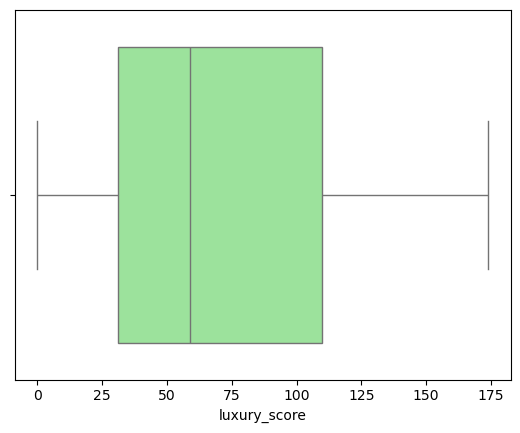

In [93]:
sns.boxplot(x=df['luxury_score'],color = 'lightgreen')

# OBSERVATION
* Luxury score column has multiple peaks which denotes that it has multi-modal distribution
* There is a significant number of properties between 0-50 and 110-130
* There is no null value
* The boxplot suggests that the majority of the value lies between 30-110

In [94]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


In [95]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')